In [21]:
import os
import sys

import cv2
import numpy as np
from IPython.display import Image, display

NB_DIR = os.path.abspath(os.getcwd())
if NB_DIR not in sys.path:
    sys.path.insert(0, NB_DIR)

from utils.csv_io import load_whisker_csv
from utils.mask_utils import points_to_mask
from utils.flow_tracker import track_whisker, CONFIG
from utils.viz import save_prediction

In [22]:
TRAINING_IMAGE   = "/Users/martindokholyan/Desktop/052725_1_1626/images/img0054750.png"
TRAINING_CSV     = "/Users/martindokholyan/Desktop/052725_1_1626/labels/1/0054750.csv"
PREDICTION_IMAGE = "/Users/martindokholyan/Desktop/052725_1_1626/images/img0035455.png"

USE_AUGMENTATION_VOTING = False  # set True to enable ensemble voting (slower)

In [23]:
train_img = cv2.imread(TRAINING_IMAGE, cv2.IMREAD_UNCHANGED)
if train_img is None:
    raise FileNotFoundError(f"Could not read training image: {TRAINING_IMAGE}")

pred_img = cv2.imread(PREDICTION_IMAGE, cv2.IMREAD_UNCHANGED)
if pred_img is None:
    raise FileNotFoundError(f"Could not read prediction image: {PREDICTION_IMAGE}")

points = load_whisker_csv(TRAINING_CSV)
train_mask = points_to_mask(points, train_img.shape, line_width=3)

train_frame = os.path.splitext(os.path.basename(TRAINING_CSV))[0]
pred_stem   = os.path.splitext(os.path.basename(PREDICTION_IMAGE))[0]
pred_frame  = pred_stem[3:] if pred_stem.startswith("img") else pred_stem

print(f"Training image:    {TRAINING_IMAGE}")
print(f"  shape:           {train_img.shape}, dtype: {train_img.dtype}")
print(f"Training CSV:      {TRAINING_CSV}")
print(f"  whisker points:  {len(points)}")
print(f"  training frame:  {train_frame}")
print(f"Prediction image:  {PREDICTION_IMAGE}")
print(f"  shape:           {pred_img.shape}, dtype: {pred_img.dtype}")
print(f"  prediction frame: {pred_frame}")
print(f"Reference mask sum: {int(train_mask.sum())} pixels")

Training image:    /Users/martindokholyan/Desktop/052725_1_1626/images/img0054750.png
  shape:           (480, 640), dtype: uint8
Training CSV:      /Users/martindokholyan/Desktop/052725_1_1626/labels/1/0054750.csv
  whisker points:  919
  training frame:  0054750
Prediction image:  /Users/martindokholyan/Desktop/052725_1_1626/images/img0035455.png
  shape:           (480, 640), dtype: uint8
  prediction frame: 0035455
Reference mask sum: 2172 pixels


In [24]:
CONFIG['use_augmentation_voting'] = USE_AUGMENTATION_VOTING
result = track_whisker(train_img, train_mask, pred_img, CONFIG)

print(f"predicted_mask:   shape={result['predicted_mask'].shape}, "
      f"dtype={result['predicted_mask'].dtype}, "
      f"sum={int(result['predicted_mask'].sum())}")
print(f"confidence_map:   shape={result['confidence_map'].shape}, "
      f"dtype={result['confidence_map'].dtype}, "
      f"max={float(result['confidence_map'].max()):.4f}")
print(f"refined_points:   shape={result['refined_points'].shape}")

predicted_mask:   shape=(480, 640), dtype=uint8, sum=3398
confidence_map:   shape=(480, 640), dtype=float32, max=0.9701
refined_points:   shape=(60, 2)


Saved: /Users/martindokholyan/Desktop/052725_1_1626/predictions/img0035455_pred.png


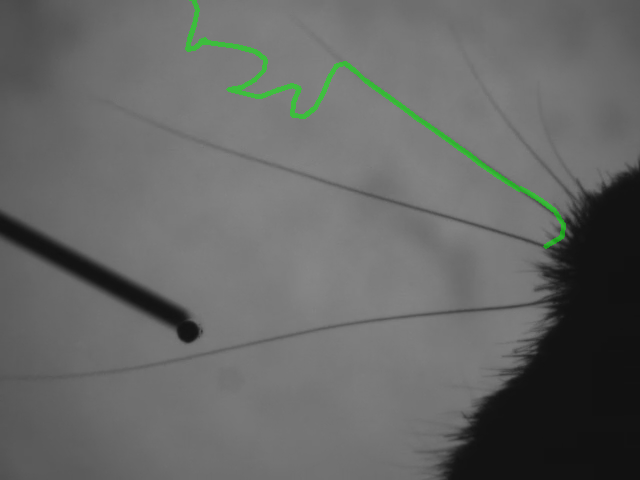

In [25]:
output_path = PREDICTION_IMAGE.replace('/images/', '/predictions/').replace('.png', '_pred.png')

save_prediction(pred_img, result['predicted_mask'], output_path)
print(f"Saved: {output_path}")
display(Image(output_path))